In [148]:
import os
from pathlib import Path
from shutil import copy2

In [149]:
from pathlib import Path
import os
from shutil import copy2

datasets = ["dataset1", "dataset2", "dataset3", "dataset4"]
dataset_ids = ["ds1", "ds2", "ds3", "ds4"]

merged_folder = "merged_dataset"
os.makedirs(merged_folder, exist_ok=True)

for ds_path, ds_id in zip(datasets, dataset_ids):
    ds_path = Path(ds_path)

    for class_folder in ds_path.iterdir():
        if class_folder.is_dir():   # FIXED HERE
            target_class = Path(merged_folder) / class_folder.name
            target_class.mkdir(exist_ok=True)

            for img in class_folder.iterdir():
                if img.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".dcm"]:
                    new_name = f"{ds_id}_{img.name}"
                    copy2(img, target_class / new_name)

print("Merge complete! All datasets are now in", merged_folder)

Merge complete! All datasets are now in merged_dataset


In [150]:
from pathlib import Path
from shutil import copy2

source_dir = Path("merged_dataset")
target_dir = Path("merged_3class")

CLASS_MAP = {
    "A": "M",
    "B": "B",
    "C": "M",
    "L": "M",
    "M": "M",
    "N": "N"
}

for cls in ["B", "M", "N"]:
    (target_dir / cls).mkdir(parents=True, exist_ok=True)

for class_folder in source_dir.iterdir():
    if not class_folder.is_dir():
        continue

    original_class = class_folder.name
    if original_class not in CLASS_MAP:
        continue

    new_class = CLASS_MAP[original_class]

    for img in class_folder.iterdir():
        if img.suffix.lower() in [
            ".png", ".jpg", ".jpeg", ".bmp",
            ".tif", ".tiff", ".dcm"
        ]:
            # unique filename
            new_name = f"{original_class}_{img.parent.name}_{img.name}"
            copy2(img, target_dir / new_class / new_name)

print("Class remapping complete without overwrites!")


Class remapping complete without overwrites!


Hashing


In [151]:
import hashlib

In [152]:
def compute_md5(file_path, block_size=65536):
    md5 = hashlib.md5()
    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(block_size), b""):
            md5.update(chunk)
    return md5.hexdigest()


In [153]:
DATASET_DIR = Path("merged_3class")
hash_to_file = {}      # md5 -> first seen file
duplicate_files = []  # files to be removed

valid_ext = {
    ".png", ".jpg", ".jpeg", ".bmp",
    ".tif", ".tiff", ".dcm"
}

for class_dir in DATASET_DIR.iterdir():
    if not class_dir.is_dir():
        continue

    for img_path in class_dir.iterdir():
        if img_path.suffix.lower() not in valid_ext:
            continue

        file_hash = compute_md5(img_path)

        if file_hash in hash_to_file:
            duplicate_files.append(img_path)
        else:
            hash_to_file[file_hash] = img_path


In [154]:
print(f"Total duplicate images detected: {len(duplicate_files)}")

print("\nSample duplicates:")
for dup in duplicate_files[:10]:
    print(dup)

for dup in duplicate_files:
    dup.unlink()

print("\nDuplicate images removed successfully.")


Total duplicate images detected: 2385

Sample duplicates:
merged_3class\B\B_B_ds1_100-001 (258).dcm.png
merged_3class\B\B_B_ds1_100-001 (259).dcm.png
merged_3class\B\B_B_ds1_100-001 (260).dcm.png
merged_3class\B\B_B_ds1_100-001 (261).dcm.png
merged_3class\B\B_B_ds1_100-001 (262).dcm.png
merged_3class\B\B_B_ds1_100-001 (263).dcm.png
merged_3class\B\B_B_ds1_100-001 (264).dcm.png
merged_3class\B\B_B_ds1_100-001 (265).dcm.png
merged_3class\B\B_B_ds1_100-001 (266).dcm.png
merged_3class\B\B_B_ds1_100-001 (267).dcm.png

Duplicate images removed successfully.


Stretching and Min max Normalization

In [ ]:
from pathlib import Path
import cv2
import numpy as np

def enhance_contrast_extended(img, lower=-50, upper=305):
    img = img.astype(np.float32)
    orig_min = img.min()
    orig_max = img.max()
    stretched = (img - orig_min) / (orig_max - orig_min + 1e-8) * (upper - lower) + lower
    enhanced = np.clip(stretched, 0, 255)
    return enhanced.astype(np.uint8)

# Paths
dataset_dir = Path("merged_3class")          # your deduplicated dataset
enhanced_dir = Path("merged_3class_enhanced")  
enhanced_dir.mkdir(exist_ok=True)

# Process classes
for cls_folder in dataset_dir.iterdir():
    if not cls_folder.is_dir():
        continue
    target_cls_folder = enhanced_dir / cls_folder.name
    target_cls_folder.mkdir(exist_ok=True)

    for img_file in cls_folder.iterdir():
        if img_file.suffix.lower() not in [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".dcm"]:
           
            continue

        img = cv2.imread(str(img_file), cv2.IMREAD_GRAYSCALE)
        enhanced_img = enhance_contrast_extended(img, lower=-50, upper=305)

        save_path = target_cls_folder / img_file.name
        cv2.imwrite(str(save_path), enhanced_img)


Hashing After Enhancement


In [161]:
from pathlib import Path
import hashlib

def compute_md5(file_path, block_size=65536):
    """
    Compute MD5 hash of a file using chunked reading
    """
    md5 = hashlib.md5()
    with open(file_path, "rb") as f:
        for block in iter(lambda: f.read(block_size), b""):
            md5.update(block)
    return md5.hexdigest()


DATASET_DIR = Path("merged_3class_enhanced")  # change if needed

hash_to_file = {}      # md5 -> first seen file
duplicate_files = []  # files to be removed

valid_ext = {
    ".png", ".jpg", ".jpeg", ".bmp",
    ".tif", ".tiff", ".dcm"
}

for class_dir in DATASET_DIR.iterdir():
    if not class_dir.is_dir():
        continue

    for img_path in class_dir.iterdir():
        if img_path.suffix.lower() not in valid_ext:
            continue

        file_hash = compute_md5(img_path)

        if file_hash in hash_to_file:
            duplicate_files.append(img_path)
        else:
            hash_to_file[file_hash] = img_path


print(f"Total duplicate images detected: {len(duplicate_files)}")

print("\nSample duplicates:")
for dup in duplicate_files[:10]:
    print(dup)

# Remove duplicates
for dup in duplicate_files:
    dup.unlink()

print("\nDuplicate images removed successfully.")


Total duplicate images detected: 2385

Sample duplicates:
merged_3class_enhanced\B\B_B_ds1_100-001 (258).dcm.png
merged_3class_enhanced\B\B_B_ds1_100-001 (259).dcm.png
merged_3class_enhanced\B\B_B_ds1_100-001 (260).dcm.png
merged_3class_enhanced\B\B_B_ds1_100-001 (261).dcm.png
merged_3class_enhanced\B\B_B_ds1_100-001 (262).dcm.png
merged_3class_enhanced\B\B_B_ds1_100-001 (263).dcm.png
merged_3class_enhanced\B\B_B_ds1_100-001 (264).dcm.png
merged_3class_enhanced\B\B_B_ds1_100-001 (265).dcm.png
merged_3class_enhanced\B\B_B_ds1_100-001 (266).dcm.png
merged_3class_enhanced\B\B_B_ds1_100-001 (267).dcm.png

Duplicate images removed successfully.


Enhancement Result

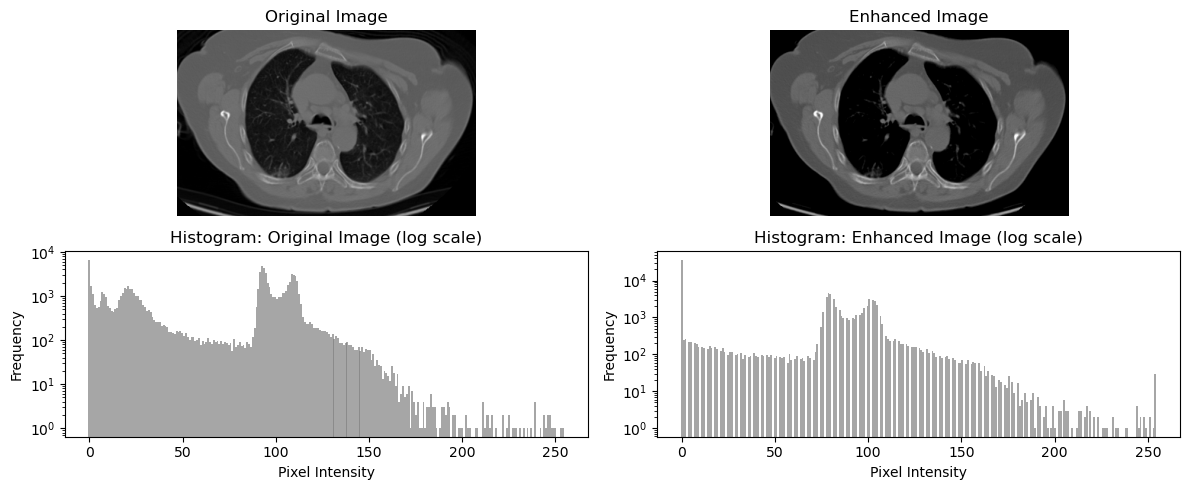

In [162]:
import matplotlib.pyplot as plt
img_path = "merged_3class/M/A_A_ds2_000005 (9).png"  # change this to your path
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Enhance
enhanced_img = enhance_contrast_extended(img, lower=-50, upper=305)



# Original Image
plt.figure(figsize=(12,5))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(enhanced_img, cmap='gray')
plt.title("Enhanced Image")
plt.axis('off')

# Plot histograms
plt.subplot(2,2,3)
hist_orig, bins_orig = np.histogram(img.ravel(), bins=256, range=(0,255))
plt.bar(bins_orig[:-1], hist_orig, width=1, color='gray', alpha=0.7)
plt.yscale('log')  # Log frequency
plt.title("Histogram: Original Image (log scale)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.subplot(2,2,4)
hist_enh, bins_enh = np.histogram(enhanced_img.ravel(), bins=256, range=(0,255))
plt.bar(bins_enh[:-1], hist_enh, width=1, color='gray', alpha=0.7)
plt.yscale('log')  # Log frequency
plt.title("Histogram: Enhanced Image (log scale)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [157]:
#import sys
#print(sys.executable)


Data Resizing

In [14]:
from pathlib import Path

INPUT_DIR = Path("merged_3class_enhanced")
OUTPUT_DIR = Path("resized_512_padded")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [15]:
import cv2
import numpy as np
from pathlib import Path

TARGET_SIZE = 512
EXTENSIONS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".dcm")

def resize_with_padding(img, target_size=512):
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv2.resize(
        img,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )

    padded = np.zeros((target_size, target_size), dtype=resized.dtype)

    y_offset = (target_size - new_h) // 2
    x_offset = (target_size - new_w) // 2

    padded[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = resized

    return padded


# process dataset
for class_dir in INPUT_DIR.iterdir():
    if not class_dir.is_dir():
        continue

    out_class_dir = OUTPUT_DIR / class_dir.name
    out_class_dir.mkdir(parents=True, exist_ok=True)

    for img_path in class_dir.iterdir():
        if not img_path.is_file():
            continue

        if img_path.suffix.lower() not in EXTENSIONS:
            continue

        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        resized_img = resize_with_padding(img)

        cv2.imwrite(
            str(out_class_dir / img_path.name),
            resized_img
        )


(512, 512)


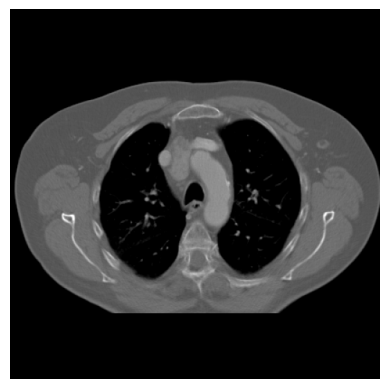

In [16]:
import cv2
import matplotlib.pyplot as plt

sample = next((OUTPUT_DIR / "M").glob("*.png"))
img = cv2.imread(str(sample), cv2.IMREAD_GRAYSCALE)

print(img.shape)  # (512, 512)

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()


In [17]:
import sys
print(sys.version)


3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]


In [18]:
import os
import cv2 as cv
import numpy as np
from skimage import measure
from skimage.segmentation import clear_border
from sklearn.cluster import KMeans



In [71]:
import cv2 as cv
import numpy as np
from sklearn.cluster import KMeans
from skimage.segmentation import clear_border
from skimage import measure


def generate_lung_mask(ct_img):
    # A: Image Negation
    neg_img = cv.bitwise_not(ct_img)

    # B: K-means Thresholding
    flat = neg_img.reshape(-1, 1).astype(np.float32)
    kmeans = KMeans(n_clusters=2, n_init=10, random_state=42).fit(flat)

    centers = np.sort(kmeans.cluster_centers_.flatten())
    threshold = np.mean(centers)

    _, binary = cv.threshold(
        neg_img,
        threshold,
        255,
        cv.THRESH_BINARY
    )

    # C: Clear Border Objects
    cleared = clear_border(binary)

    # D: Connected Component Labeling
    labels = measure.label(cleared)
    regions = measure.regionprops(labels)

    if len(regions) < 2:
        return neg_img

    # -------------------------------------------------
    # Step 1: Sort by area and take top 3
    # -------------------------------------------------
    regions_sorted = sorted(regions, key=lambda r: r.area, reverse=True)
    candidates = regions_sorted[:3]

    # -------------------------------------------------
    # Step 2: If only 2 exist, keep them
    # -------------------------------------------------
    if len(candidates) == 2:
        selected = candidates
    else:
        # -------------------------------------------------
        # Step 3: Compute widths
        # -------------------------------------------------
        widths = np.array([r.bbox[3] - r.bbox[1] for r in candidates])

        # Pairwise distance matrix
        dist = np.zeros(3)
        for i in range(3):
            for j in range(3):
                if i != j:
                    dist[i] += abs(widths[i] - widths[j])

        # -------------------------------------------------
        # Step 4: Remove the most dissimilar one
        # -------------------------------------------------
        remove_idx = np.argmax(dist)
        selected = [r for i, r in enumerate(candidates) if i != remove_idx]

    # -------------------------------------------------
    # Step 5: Build lung mask
    # -------------------------------------------------
    lung_mask = np.zeros_like(labels, dtype=np.uint8)

    for r in selected:
        lung_mask[labels == r.label] = 255

    # -------------------------------------------------
    # Step 6: Morphological cleanup
    # -------------------------------------------------
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))

    lung_mask = cv.morphologyEx(lung_mask, cv.MORPH_OPEN, kernel)
    lung_mask = cv.morphologyEx(lung_mask, cv.MORPH_CLOSE, kernel)

    contours, _ = cv.findContours(
        lung_mask,
        cv.RETR_EXTERNAL,
        cv.CHAIN_APPROX_SIMPLE
    )
    cv.drawContours(
        lung_mask,
        contours,
        -1,
        255,
        thickness=cv.FILLED
    )

    # -------------------------------------------------
    # Step 7: Apply mask
    # -------------------------------------------------
    masked_img = cv.bitwise_and(
        neg_img,
        neg_img,
        mask=lung_mask
    )

    return masked_img


In [74]:
img = r"D:\ResearchPaper\resized_512_padded\N\N_N_ds3_Normal case (354).jpg"
ct_image = cv.imread(img,cv.IMREAD_GRAYSCALE)
img_f = generate_lung_mask(ct_image)
cv.imshow('IMG',img_f)
cv.waitKey(0)
cv.destroyAllWindows()

In [ ]:
# Input and output directories
INPUT_DIR = r"D:\ResearchPaper\resized_512_padded"
OUTPUT_DIR = r"D:\ResearchPaper\masked_512"

classes = ["B", "M", "N"]

# Create output folders
for cls in classes:
    os.makedirs(os.path.join(OUTPUT_DIR, cls), exist_ok=True)

# Process images
for cls in classes:
    input_class_dir = os.path.join(INPUT_DIR, cls)
    output_class_dir = os.path.join(OUTPUT_DIR, cls)

    for filename in os.listdir(input_class_dir):

        if filename.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".dcm")):
            img_path = os.path.join(input_class_dir, filename)

            # Read grayscale CT image
            img = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
            if img is None:
                continue

            # Ensure 512x512
            img = cv.resize(img, (512, 512))

            # Generate masked image
            masked_img = generate_lung_mask(img)

            # Save output
            save_path = os.path.join(output_class_dir, filename)
            cv.imwrite(save_path, masked_img)

    print(f"Finished processing class: {cls}")
